# Understanding the Impact of State Level Funding on Student Outcomes
## CS 1090A Final Project
### by Alex Fernand, Moniola, Grace Augustine, and Garland Catlette

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.formula.api as smf
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.utils import resample
from scipy.stats import t
from sklearn.metrics import mean_squared_error, r2_score

## Exploratory Data Analysis

In [25]:
df = pd.read_excel("data/StateIndicatorsDatabase_2025.xlsx", sheet_name="Data")

# Filtering data for the years 2009 to 2019 to address missingness
df = df[(df["year"] >= 2009) & (df["year"] <= 2019)]
df.head()

/Users/garlandcatlette/FALL25/CS_1090A/final_project/.venv/lib/python3.13/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


,year,stabbr,state_name,statefip,region4,region9,effort,inc_effort,predicted_fedrevpp0_,predicted_fedrevpp10_,...,inc_gap130_ratio,coverage,state_chartershare,inc_pubsch,inc_nonpubsch,pubprv_incratio,case,citation,ruling,casetype
153,2019,AL,Alabama,1,South,East South Central,0.035605,0.038865,431.6210,686.7686,...,0.197983,0.861250,0.000795,82750.59,125697.30,0.658332,NaN,NaN,NaN,NaN
154,2019,AK,Alaska,2,West,Pacific,0.042915,0.053074,753.8663,1773.2300,...,0.225739,0.853597,0.055628,98056.77,87579.52,1.119631,NaN,NaN,NaN,NaN
155,2019,AZ,Arizona,4,West,Mountain,0.026370,0.029332,325.9877,613.1902,...,0.196911,0.895027,0.306565,101541.70,127656.70,0.795428,NaN,NaN,NaN,NaN
156,2019,AR,Arkansas,5,South,West South Central,0.042158,0.042279,512.3929,779.2733,...,0.214611,0.902905,0.075659,79239.53,120330.90,0.658514,NaN,NaN,NaN,NaN
157,2019,CA,California,6,West,Pacific,0.031838,0.038167,421.1313,749.0176,...,0.164208,0.901418,0.141387,125382.30,209634.50,0.598100,NaN,NaN,NaN,NaN


In [26]:
predictors_of_interest = ["year", "state_name", "region4", "region9", "necm_ppcstot_state", "necm_fundinggap_state",
 "tchsalary25_30", "tchsalary31_40", "tchsalary41_50", "tchsalary51_60", "necm_outcomegap_q1", "necm_outcomegap_q2", 
 "necm_outcomegap_q3", "necm_outcomegap_q4", "necm_outcomegap_q5", "fairness_tchph", "inc_gap185_ratio", 
 "inc_gap130_ratio"]
response_var = "necm_outcomegap_state"

#Removed states with missing data for the response variable (Vermont, Alaska, Hawaii)
filtered_df = df[predictors_of_interest + [response_var]].dropna().reset_index(drop=True)
filtered_df.head()

,year,state_name,region4,region9,necm_ppcstot_state,necm_fundinggap_state,tchsalary25_30,tchsalary31_40,tchsalary41_50,tchsalary51_60,necm_outcomegap_q1,necm_outcomegap_q2,necm_outcomegap_q3,necm_outcomegap_q4,necm_outcomegap_q5,fairness_tchph,inc_gap185_ratio,inc_gap130_ratio,necm_outcomegap_state
0,2019,Alabama,South,East South Central,10078.780,-5113.8250,22722.28,26305.53,30608.79,34383.88,0.029665,-0.330956,-0.428685,-0.430291,-0.811346,0.911271,0.242321,0.197983,-0.298386
1,2019,Arizona,West,Mountain,8542.738,-2852.4060,23866.37,27316.04,31145.49,34346.01,0.246770,-0.073577,-0.269651,-0.424496,-0.626824,0.945713,0.243701,0.196911,-0.078379
2,2019,Arkansas,South,West South Central,10147.130,-3977.7690,26109.33,30070.11,33990.20,37660.96,0.101952,-0.143908,-0.247667,-0.315275,-0.574663,1.210944,0.256912,0.214611,-0.167177
3,2019,California,West,Pacific,13433.580,-1159.8540,33505.51,39057.78,45146.67,50639.00,0.404455,0.032169,-0.213023,-0.366004,-0.514552,0.990620,0.203774,0.164208,-0.137851
4,2019,Colorado,West,Mountain,10937.760,32.1782,22873.91,26307.92,30430.89,33815.88,0.336864,0.126460,-0.138817,-0.121889,-0.205673,1.146207,0.208257,0.151715,0.107602


Text(0, 0.5, 'count')

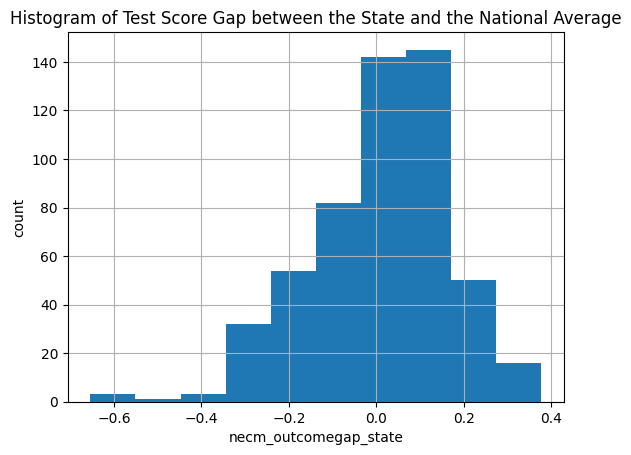

In [27]:
df['necm_outcomegap_state'].hist()
plt.title("Histogram of Test Score Gap between the State and the National Average") 
plt.xlabel("necm_outcomegap_state")
plt.ylabel("count")

_Interpretation: This histogram shows the distribution of the test score gap between the state and national average; as shown by the distribution, most states cluster around 0,  scores are close to the national average. There's a longer tail on the negative side, indicating a few states perform notably below average, while the above average outliers are seemingly less._

In [28]:
summary = pd.DataFrame({
    'NAs'      : filtered_df.isna().sum(),
    'NonNAs'   : filtered_df.notna().sum(),
    'Mean'     : filtered_df.mean(numeric_only=True),
    'Median'   : filtered_df.median(numeric_only=True),
    'STD'      : filtered_df.std(numeric_only=True),
    'IQR'      : filtered_df.quantile(0.75, numeric_only=True) - filtered_df.quantile(0.25, numeric_only=True)
})
summary.index.name = "Figure 1: Summary Statistics of Continous Predictors of Interest"

summary


,NAs,NonNAs,Mean,Median,STD,IQR
Figure 1: Summary Statistics of Continous Predictors of Interest,,,,,,
fairness_tchph,0,517,1.062278,1.040505,0.148055,0.148483
inc_gap130_ratio,0,517,0.194675,0.199068,0.030289,0.034020
inc_gap185_ratio,0,517,0.243414,0.245005,0.034649,0.040210
necm_fundinggap_state,0,517,-209.625479,-420.512100,3844.521952,4686.216000
necm_outcomegap_q1,0,517,0.282291,0.273149,0.225571,0.298808
necm_outcomegap_q2,0,517,0.102992,0.108355,0.213193,0.275957
necm_outcomegap_q3,0,517,0.003604,-0.002099,0.201970,0.299844
necm_outcomegap_q4,0,517,-0.082475,-0.073388,0.198031,0.297626
necm_outcomegap_q5,0,517,-0.301893,-0.298779,0.177266,0.258625


_Interpretation: These summary statistics show clear scale differences across our predictors; for example, necm_fundinggap_state and necm_ppcstot_state are in thousands, whilst inc_gap and outcomegap are variables with decimals between 0 and 1. This is motivation for standardizing our predictors; additionally, given the clear upward progression of teacher salary, it is probable that these variables are highly correlated with each other; thus, we may consider taking the average, instead of looking at each individually._

### Visualizing Collinearity

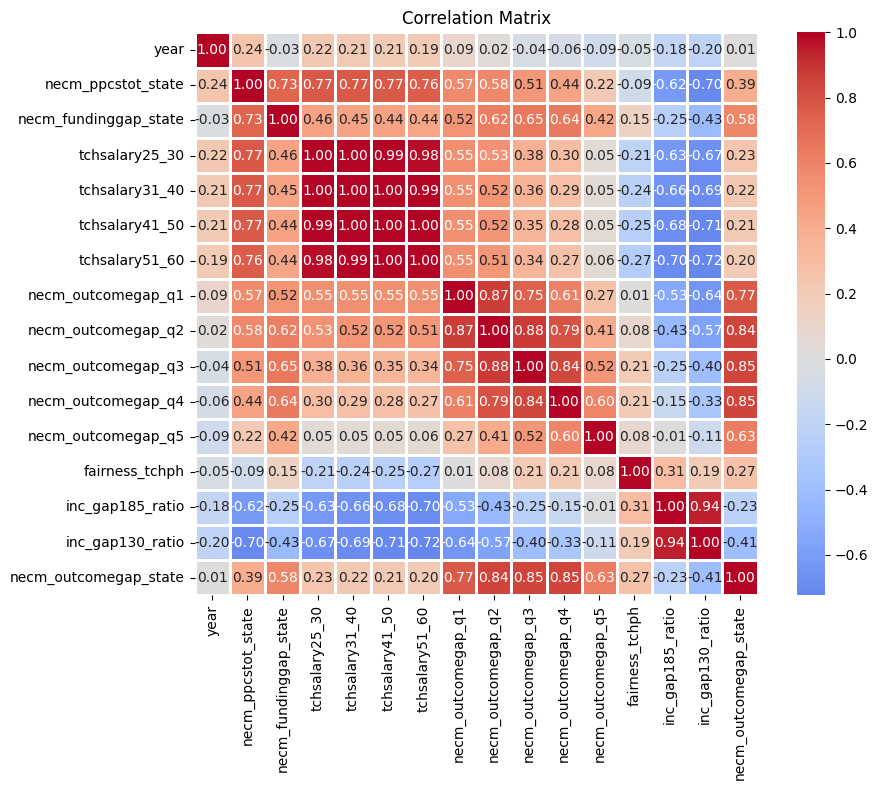

In [29]:
corr_matrix = filtered_df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

_Interpretation: The four salary variables are almost perfectly correlated with each other (0.98 - 1.00 correlation); so if we are to keep this variable, we would collapse them into one feature as keeping all four adds no new information. Inc_gap185_ratio and inc_gap130_ratio are also almost perfectly correlated; thus, we will only keep one (inc_gap185_ratio) as keeping both adds no new information. Additionally, the outcome gap quintile variables (q1-q5) are highly correlated with our outcome variable necm_outcomegap_state (0.77-0.85), which makes sense since the state average is likely a combination of the quintiles. To avoid predicting the outcome with near-proxies of itself, we drop these from our predictors._

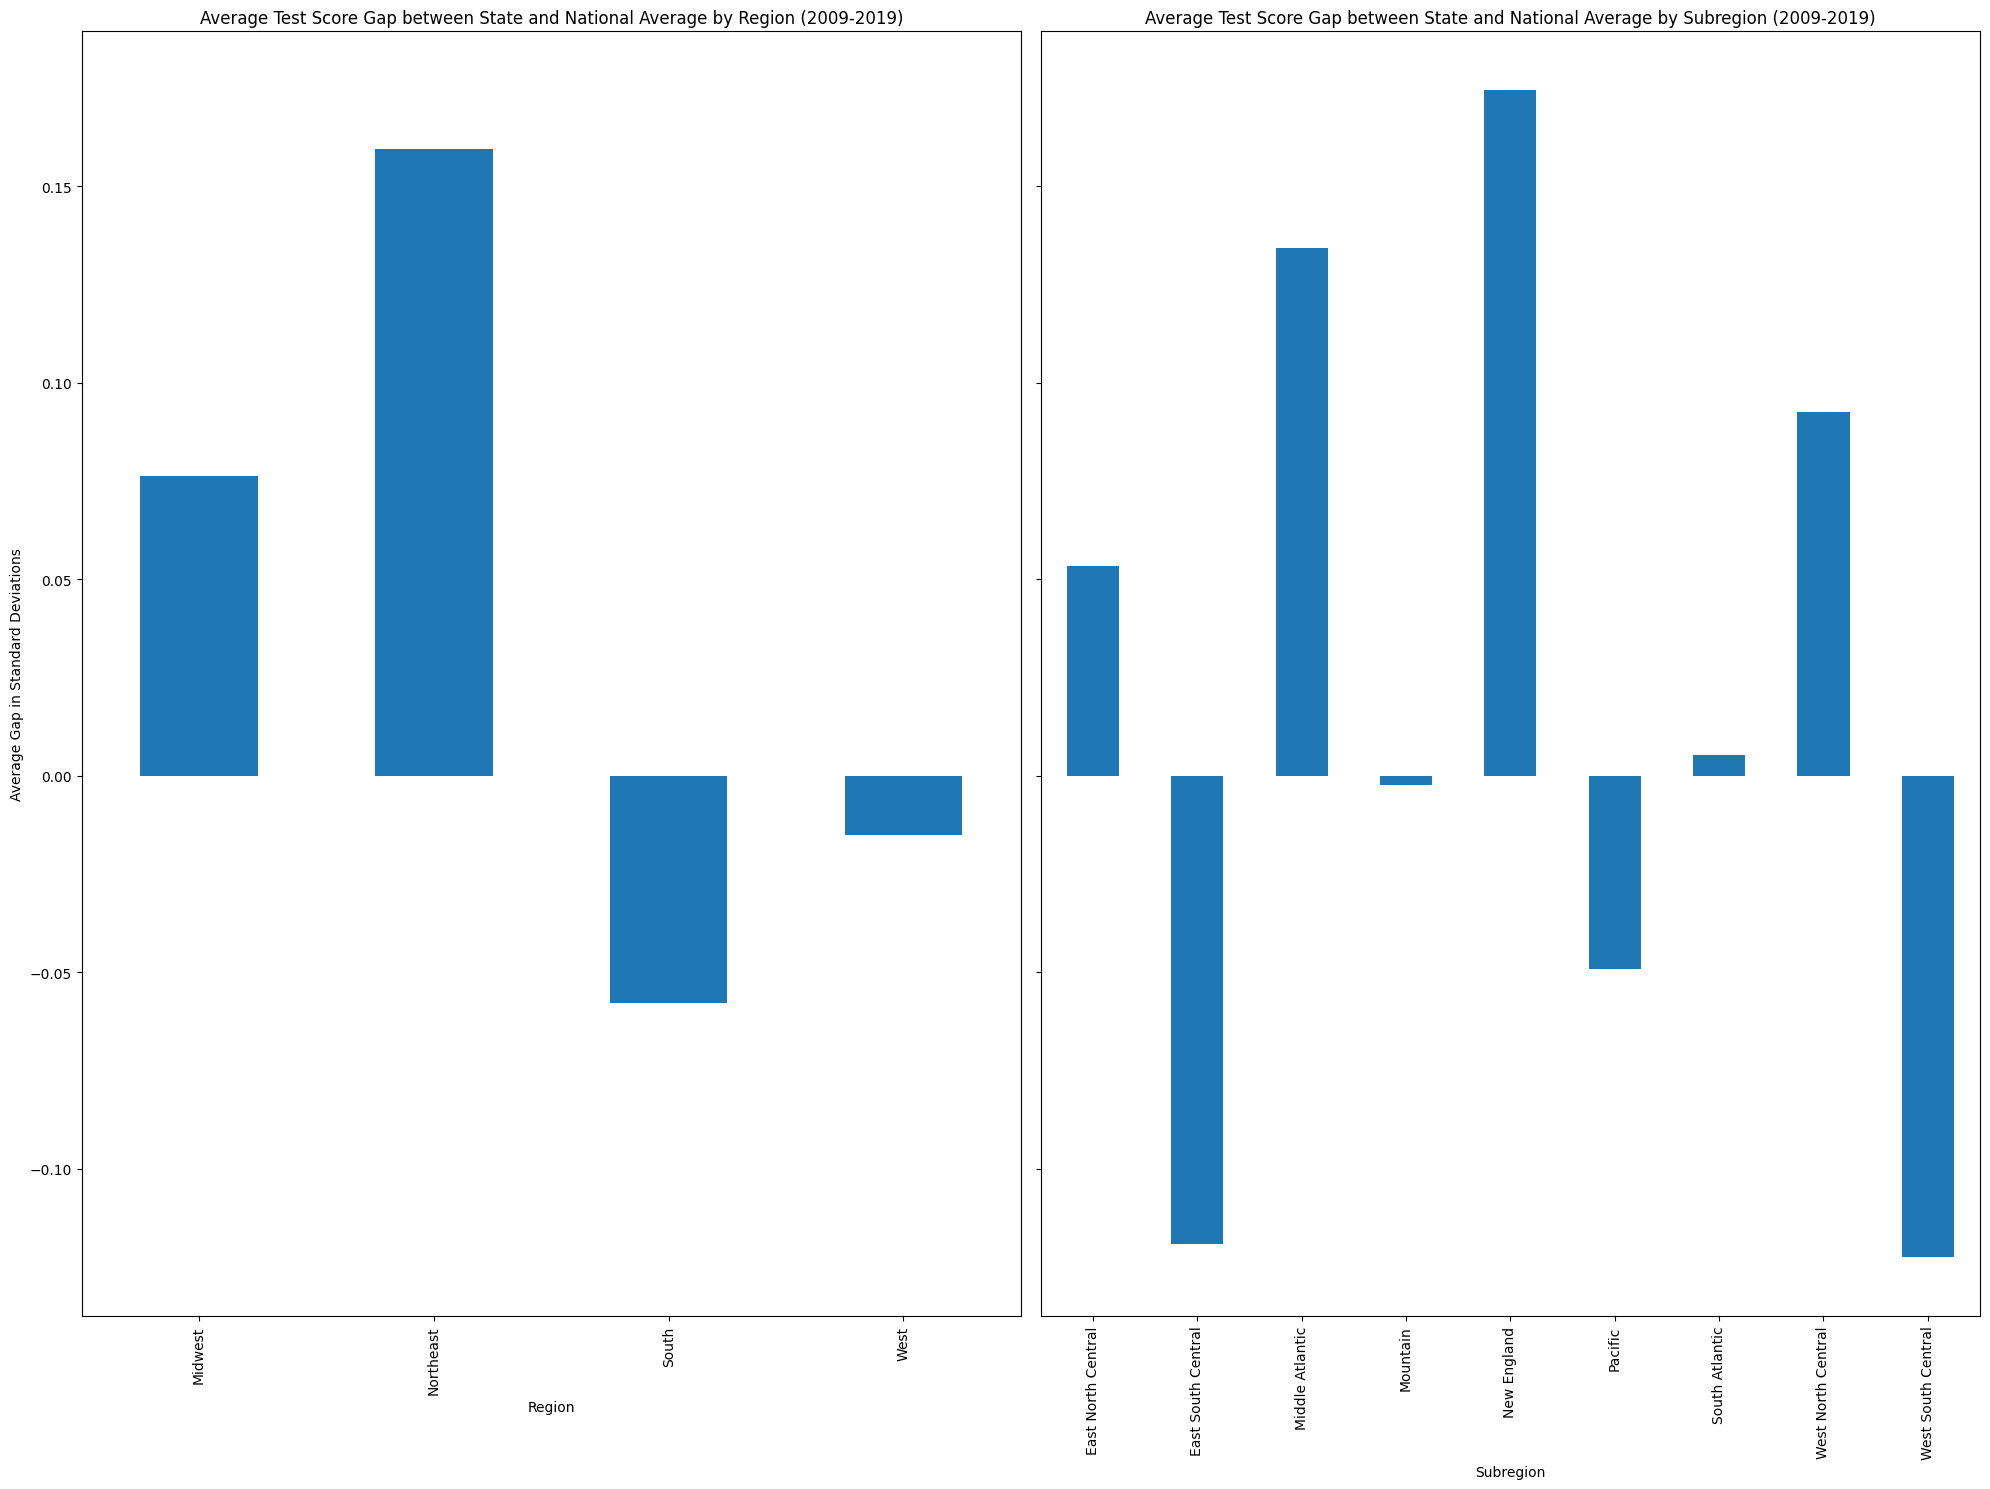

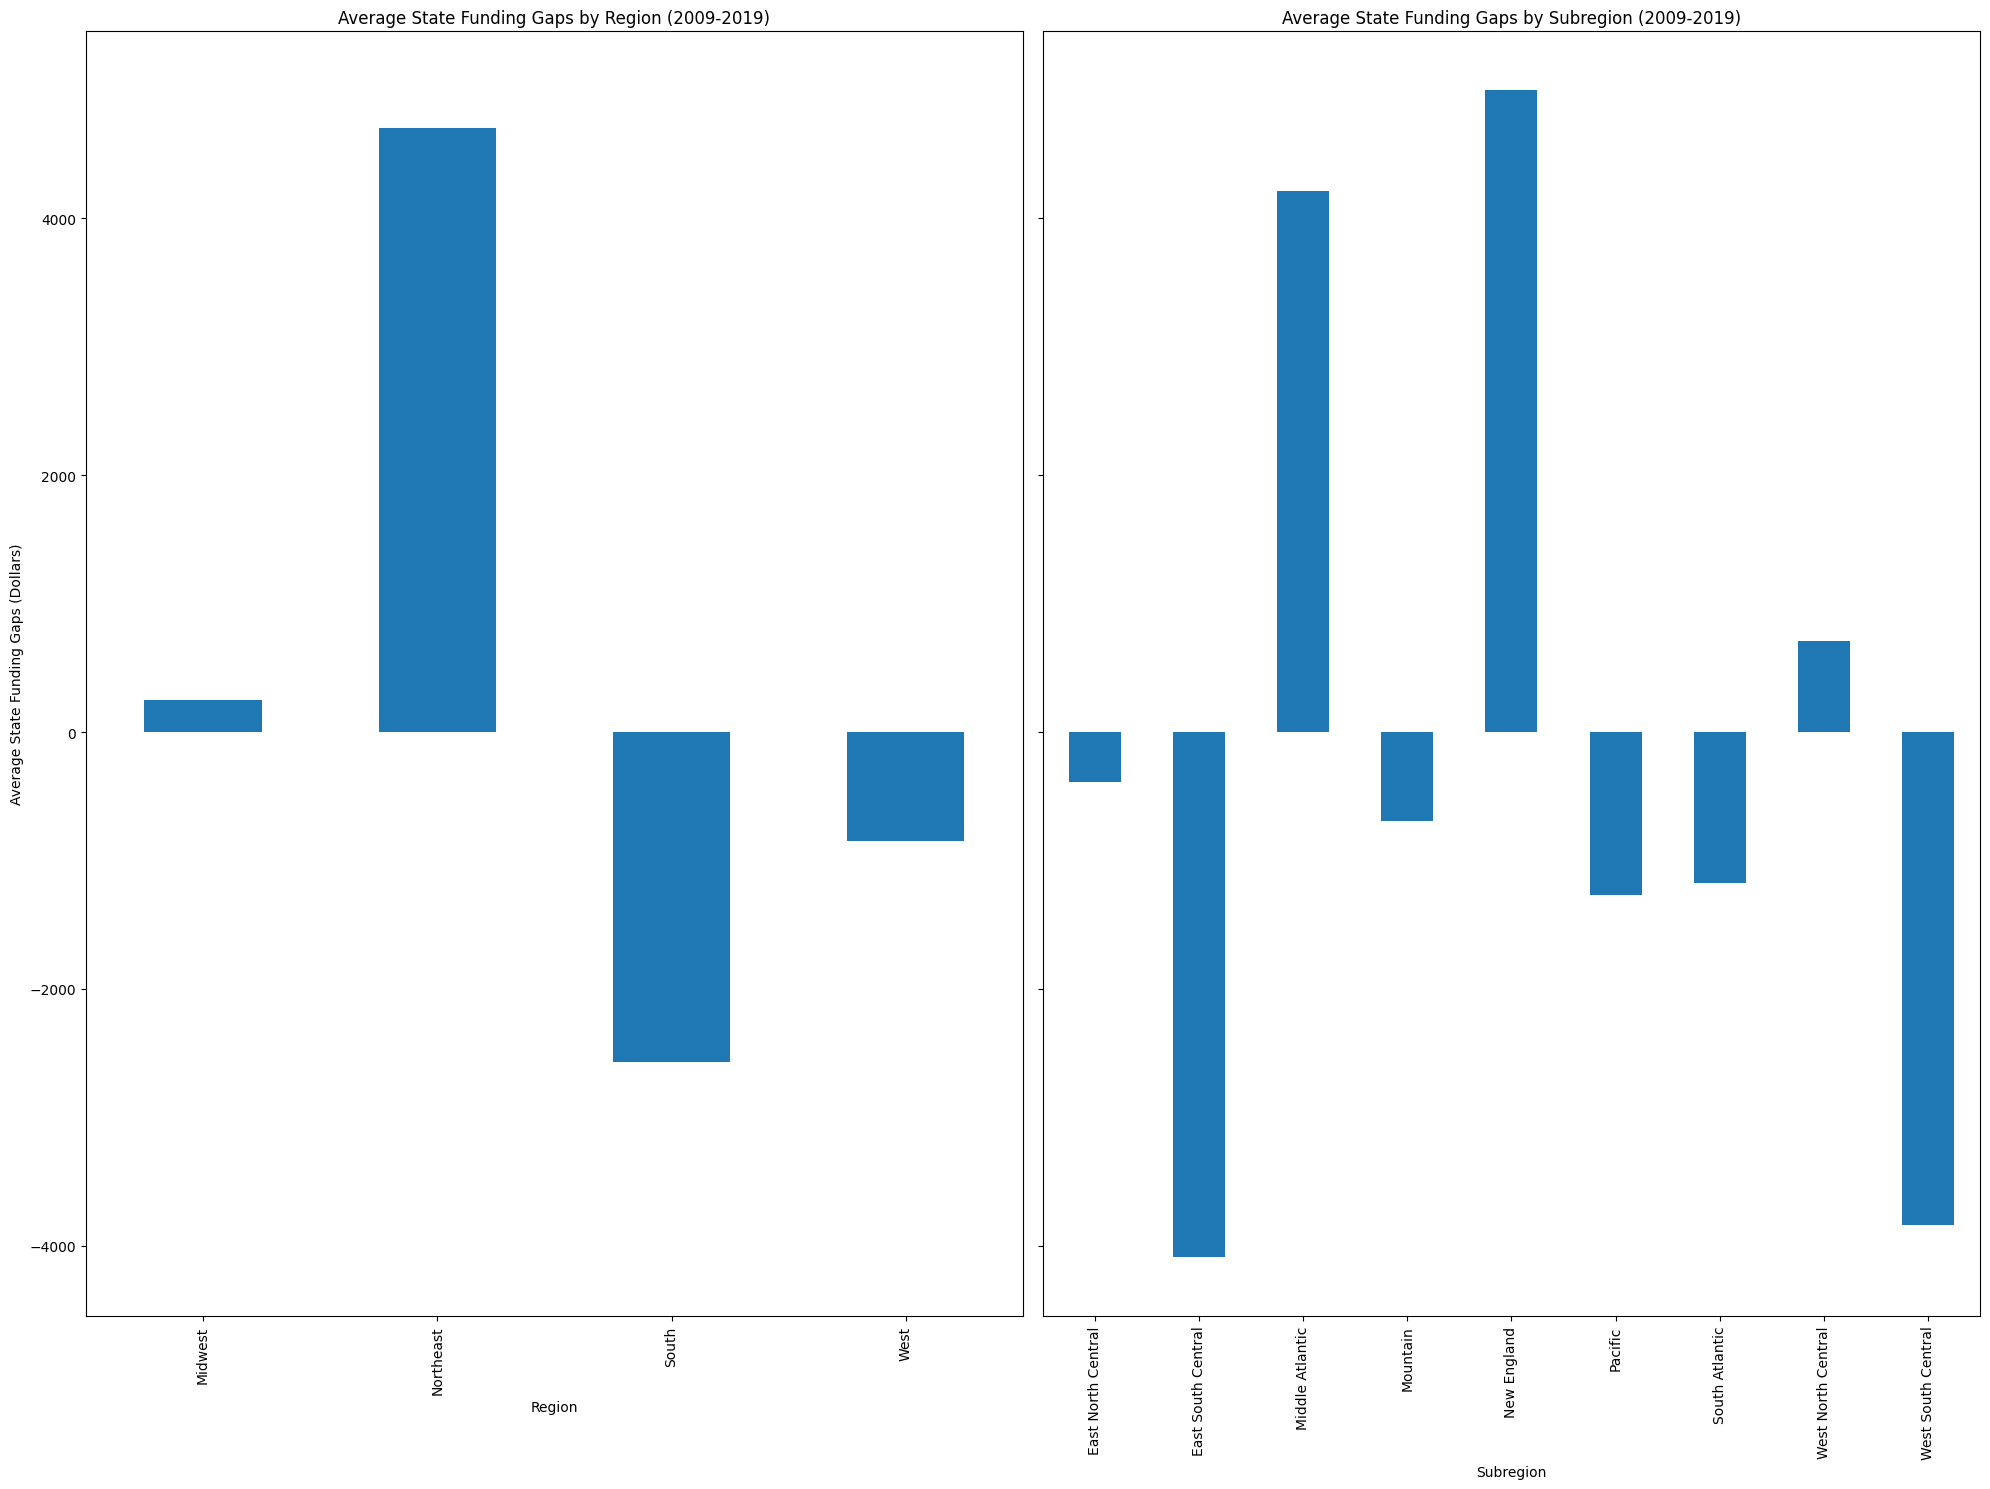

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(20, 15), sharey=True)

filtered_df.groupby("region4")[response_var].mean().plot(kind="bar", ax=axes[0])
axes[0].set_title("Average Test Score Gap between State and National Average by Region (2009-2019)")
axes[0].set_xlabel("Region")
axes[0].set_ylabel("Average Gap in Standard Deviations")

filtered_df.groupby("region9")[response_var].mean().plot(kind="bar", ax=axes[1])
axes[1].set_title("Average Test Score Gap between State and National Average by Subregion (2009-2019)")
axes[1].set_xlabel("Subregion")
axes[1].set_ylabel("Average Gap in Standard Deviations")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(20, 15), sharey=True)

filtered_df.groupby("region4")["necm_fundinggap_state"].mean().plot(kind="bar", ax=axes[0])
axes[0].set_title("Average State Funding Gaps by Region (2009-2019)")
axes[0].set_xlabel("Region")
axes[0].set_ylabel("Average State Funding Gaps (Dollars)")


filtered_df.groupby("region9")["necm_fundinggap_state"].mean().plot(kind="bar", ax=axes[1])
axes[1].set_title("Average State Funding Gaps by Subregion (2009-2019)")
axes[1].set_xlabel("Subregion")
axes[1].set_ylabel("Average State Funding Gap (Dollars)")
plt.tight_layout()
plt.show()

### Test Score Gap by State for years 2009 - 2019

##### Noteworthy Observations
* Test scores monotonically grow closer to the national average in Mississippi and the District of Columbia.
* New Hampshire consistently reports test scores above the national average, but test scores monotonically grow closer to the national average from 2013 - 2019.

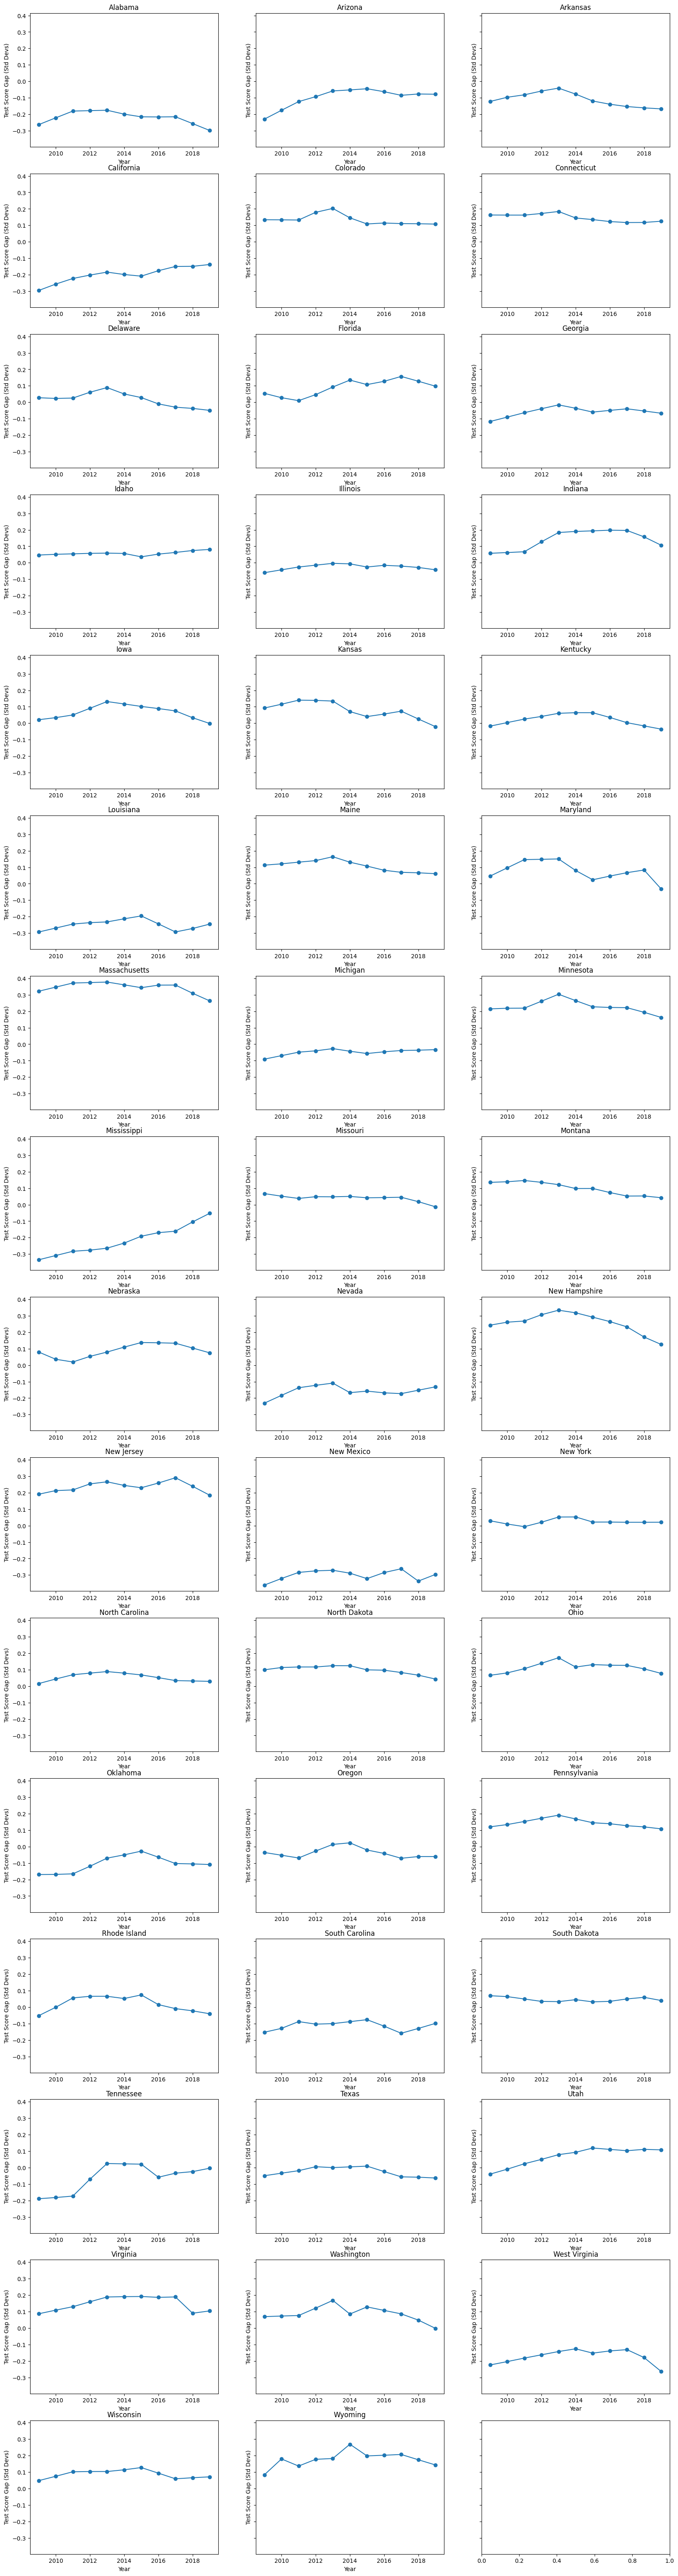

In [31]:
states = filtered_df["state_name"].unique()

fig, axes = plt.subplots(16, 3, figsize=(20, 80), sharey=True)

for state, ax in zip(states, axes.flatten()):
    state_data = filtered_df[filtered_df["state_name"] == state]
    ax.plot(state_data["year"], state_data[response_var], marker='o')
    ax.set_title(state)
    ax.set_xlabel("Year")
    ax.set_ylabel("Test Score Gap (Std Devs)")

### Updating Predictors, Feature Engineering, & Splitting Data

In [32]:
filtered_df["avg_tchsalary"] = filtered_df[["tchsalary25_30", "tchsalary31_40", "tchsalary41_50", "tchsalary51_60"]].mean(axis=1)
predictors_of_interest = ["necm_fundinggap_state", "fairness_tchph", "inc_gap185_ratio", "avg_tchsalary", "region9"]

With region being a categorical variable with more than 2 categories, it's ideal to utilize one-hot encoding to account for this.

In [33]:
X_pred = filtered_df[predictors_of_interest]
X_pred = pd.get_dummies(X_pred, columns=["region9"])

#Rename new columns created by get_dummies for clarity
X_pred.columns = ["necm_fundinggap_state", "fairness_tchph", "inc_gap185_ratio", "avg_tchsalary",
                  "east_north_central", "east_south_central", "mid_atlantic", "mountain", "new_england",
                  "pacific", "south_atlantic", "west_north_central", "west_south_central"]
X_pred.head()

,necm_fundinggap_state,fairness_tchph,inc_gap185_ratio,avg_tchsalary,east_north_central,east_south_central,mid_atlantic,mountain,new_england,pacific,south_atlantic,west_north_central,west_south_central
0,-5113.8250,0.911271,0.242321,28505.1200,False,True,False,False,False,False,False,False,False
1,-2852.4060,0.945713,0.243701,29168.4775,False,False,False,True,False,False,False,False,False
2,-3977.7690,1.210944,0.256912,31957.6500,False,False,False,False,False,False,False,False,True
3,-1159.8540,0.990620,0.203774,42087.2400,False,False,False,False,False,True,False,False,False
4,32.1782,1.146207,0.208257,28357.1500,False,False,False,True,False,False,False,False,False


In [34]:
numeric_predictors = ["necm_fundinggap_state", "fairness_tchph", "inc_gap185_ratio", "avg_tchsalary"]
X_numeric = X_pred[numeric_predictors]

scaler = StandardScaler()
X_standardized_np = scaler.fit_transform(X_numeric)
X_standardized = pd.DataFrame(X_standardized_np, columns=numeric_predictors)

for col in numeric_predictors:
    X_pred[col] = X_standardized[col]

X_pred.head()

,necm_fundinggap_state,fairness_tchph,inc_gap185_ratio,avg_tchsalary,east_north_central,east_south_central,mid_atlantic,mountain,new_england,pacific,south_atlantic,west_north_central,west_south_central
0,-1.276869,-1.020923,-0.031577,-0.337982,False,True,False,False,False,False,False,False,False
1,-0.688080,-0.788070,0.008303,-0.198371,False,False,False,True,False,False,False,False,False
2,-0.981082,1.005100,0.389928,0.388642,False,False,False,False,False,False,False,False,True
3,-0.247404,-0.484461,-1.145125,2.520529,False,False,False,False,False,True,False,False,False
4,0.062957,0.567427,-1.015633,-0.369124,False,False,False,True,False,False,False,False,False


In [35]:
y_resp = filtered_df[response_var]
X_train, X_test, y_train, y_test = train_test_split(X_pred, y_resp, test_size=0.2, random_state=42, shuffle=True)

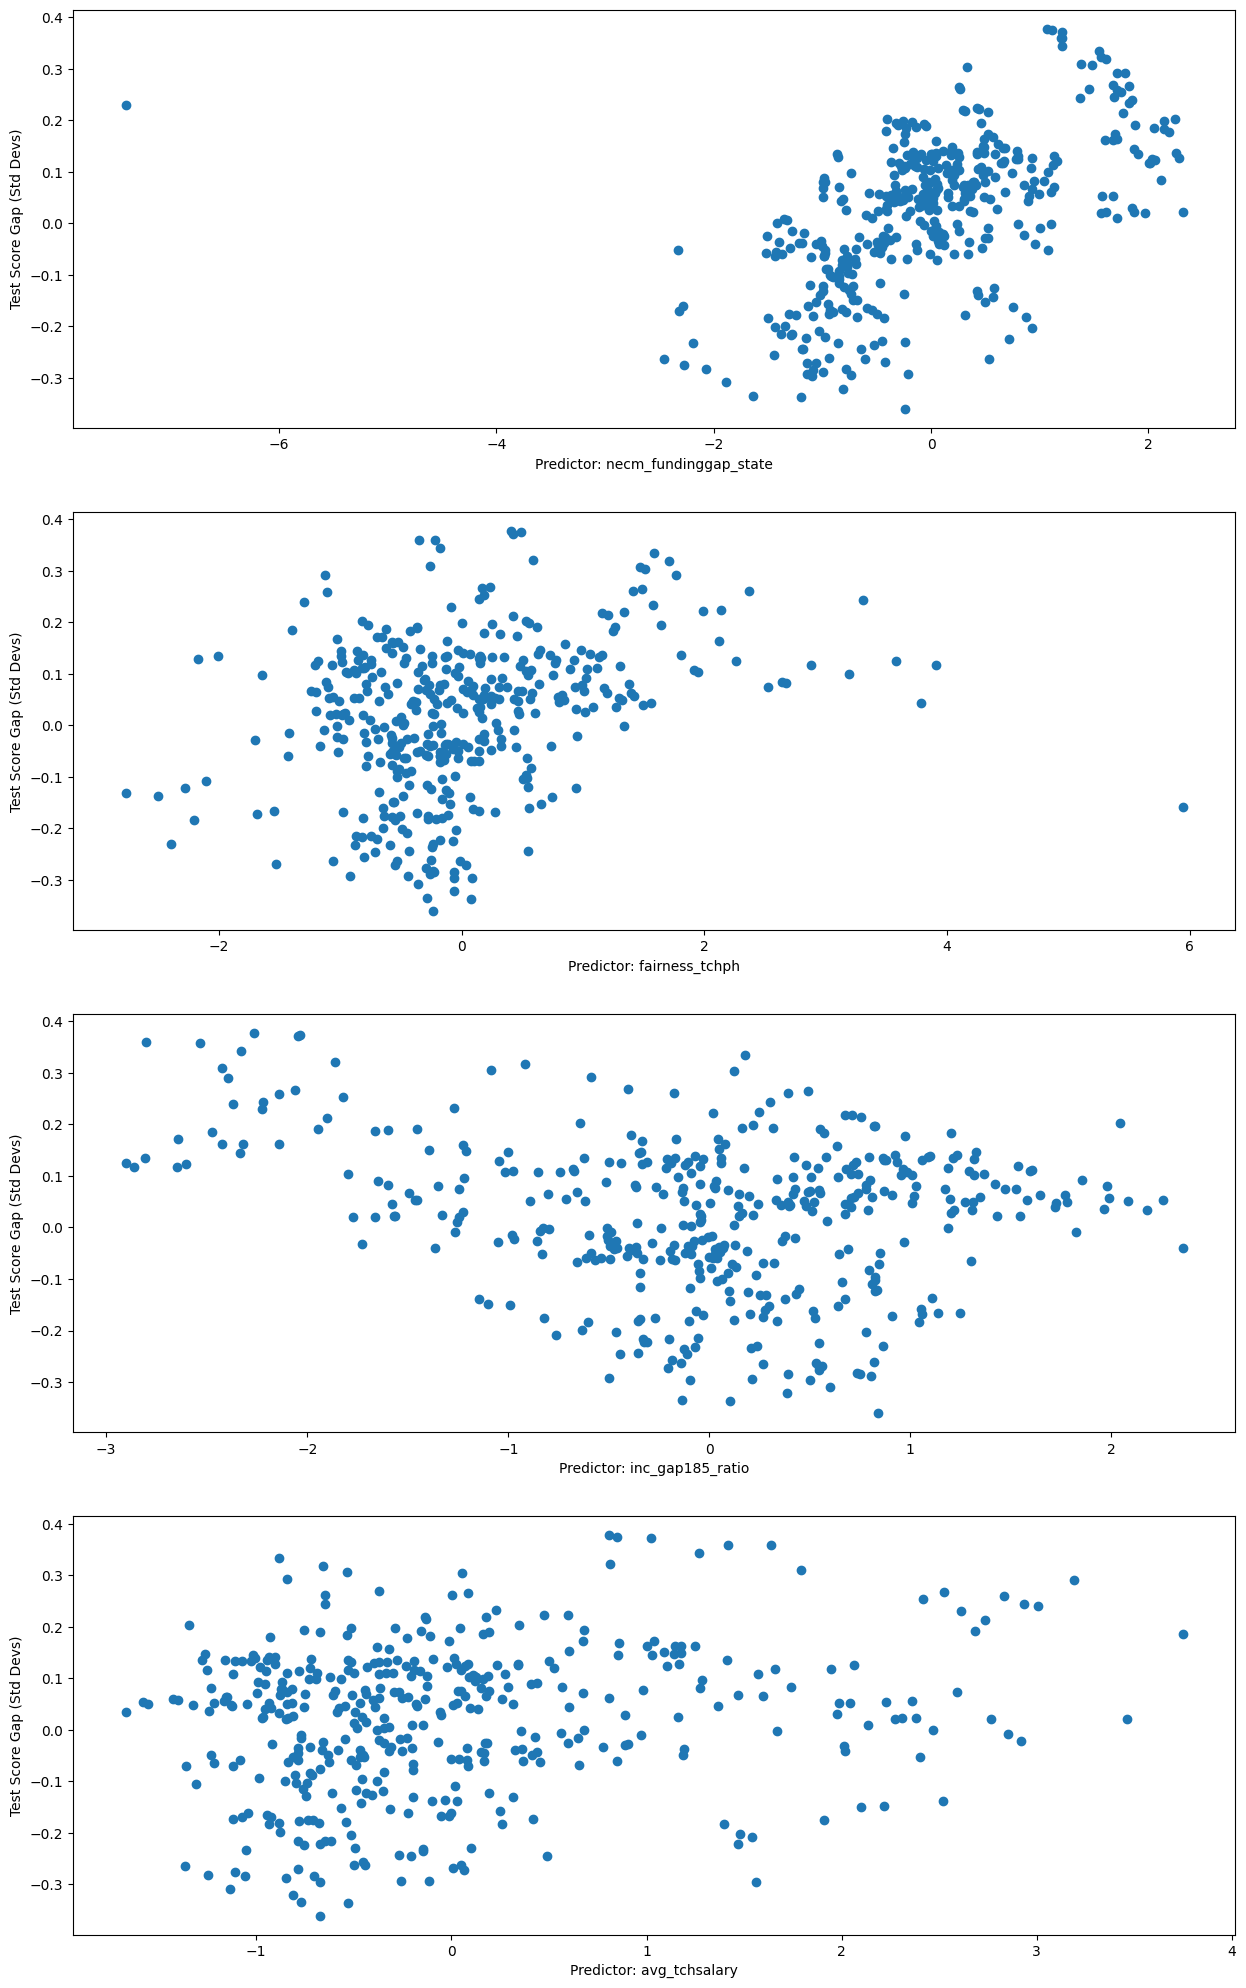

In [36]:
fig, axes = plt.subplots(4, 1, figsize=(15, 25), sharey=True)

for pred, ax in zip(numeric_predictors, axes.flatten()):
    ax.scatter(X_train[pred], y_train)
    ax.set_xlabel(f"Predictor: {pred}")
    ax.set_ylabel("Test Score Gap (Std Devs)")

Text(0, 0.5, 'Funding Gap (Dollars)')

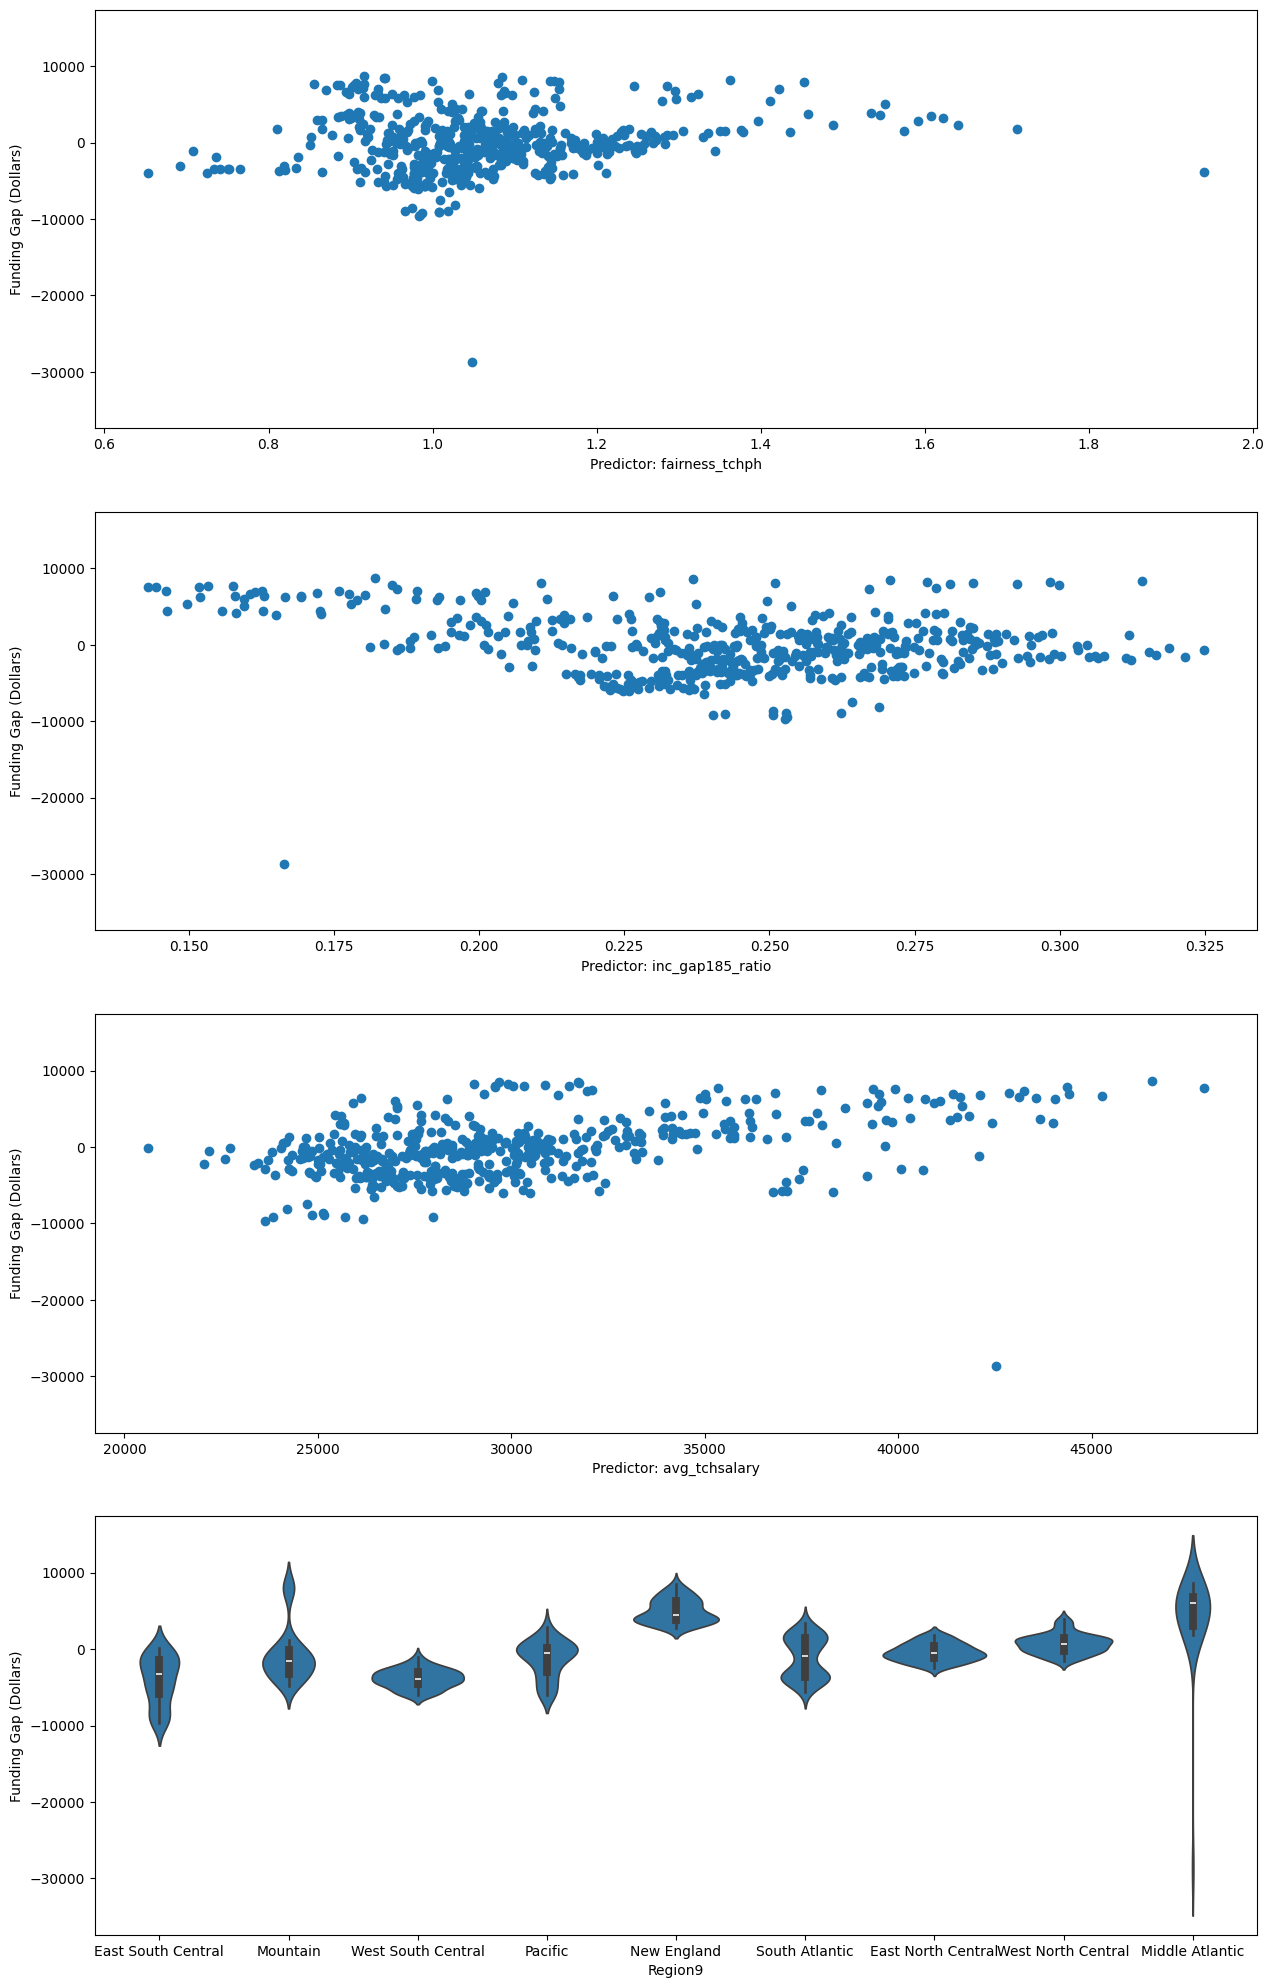

In [51]:
fig, axes = plt.subplots(4, 1, figsize=(15, 25), sharey=True)

for pred, ax in zip(predictors_of_interest[1:4], axes.flatten()[:3]):
    ax.scatter(filtered_df[pred], filtered_df["necm_fundinggap_state"])
    ax.set_xlabel(f"Predictor: {pred}")
    ax.set_ylabel("Funding Gap (Dollars)")

ax = axes.flatten()[3]
sns.violinplot(x=filtered_df["region9"], y=filtered_df["necm_fundinggap_state"], ax=ax)
ax.set_xlabel("Region9")
ax.set_ylabel("Funding Gap (Dollars)")

_Intepretation: We use these plots to further understand if there are any collinearity issues amongst our predictors; these plots show that there is not much collinearity as the relationships appear as weak/scattered clouds rather than strong linear patterns._

_Intepretation: Across these plots, the first shows a clear positive relationship. Specfically, that states with higher funding tend to have higher test scores. The second plot shows no clear relationship between fairness in teacher allocation and test scores, suggesting that this predictor is likely not very informative for the outcome. The third plot shows a negative relationship, where states with higher poverty rates tend to have worse test scores, indicating this is an important factor to control for in the regression. Finally, the last plot shows a weak positive relationship, suggesting that higher teacher salaries are only slightly associated with better outcomes._

**Feature Engineering Discussion**

_Based on the EDA, we make a few key feature adjustments. First, we collapse the four teacher salary variables into a single avg_tchsalary measure, since they are extremely highly correlated. We also drop inc_gap130_ratio due to its high corrleation with inc_gap185_ratio. In addition, we remove the outcome gap quintiles as predictors because they are essentially proxies for the outcome variable. Finally, though the scatterplots suggest that fairness_tchph has a weak relationship with test scores and may have limited predictive value, we still include it in the baseline model and allow the regression to determine its importance._

## Baseline Multiple Linear Regression Model

In [38]:
model = LinearRegression()
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [47]:
y_hat_train = model.predict(X_train)
mse_train = mean_squared_error(y_train, y_hat_train)
r2_train = r2_score(y_train, y_hat_train)
print(f"Training MSE: {mse_train}")
print(f"Training R^2: {r2_train}")


Training MSE: 0.010230452857540654
Training R^2: 0.5234689968689208


In [40]:
y_hat_test = model.predict(X_test)
mse_test = mean_squared_error(y_test, y_hat_test)
r2_test = r2_score(y_test, y_hat_test)
print(f"Testing MSE: {mse_test}")
print(f"Testing R^2: {r2_test}")

Testing MSE: 0.010687633351582146
Testing R^2: 0.40920008400478236


In [41]:
intercept = model.intercept_
coefficients = model.coef_
feature_names = X_train.columns

In [42]:
pd.DataFrame({"Coefficients": coefficients, "Predictors": feature_names})

,Coefficients,Predictors
0,0.040355,necm_fundinggap_state
1,0.031919,fairness_tchph
2,-0.041267,inc_gap185_ratio
3,-0.034660,avg_tchsalary
4,0.053251,east_north_central
5,-0.119994,east_south_central
6,0.113222,mid_atlantic
7,-0.010100,mountain
8,0.084114,new_england
9,-0.056864,pacific


In [43]:
formula = f"Y = {intercept:.4f}"
for i, coef in enumerate(coefficients):
    formula += f" + {coef:.4f} * {feature_names[i]}"

print("Multiple Linear Regression Formula:")
print(formula)

Multiple Linear Regression Formula:
Y = 0.0171 + 0.0404 * necm_fundinggap_state + 0.0319 * fairness_tchph + -0.0413 * inc_gap185_ratio + -0.0347 * avg_tchsalary + 0.0533 * east_north_central + -0.1200 * east_south_central + 0.1132 * mid_atlantic + -0.0101 * mountain + 0.0841 * new_england + -0.0569 * pacific + -0.0188 * south_atlantic + 0.0554 * west_north_central + -0.1003 * west_south_central


### Residual Analysis

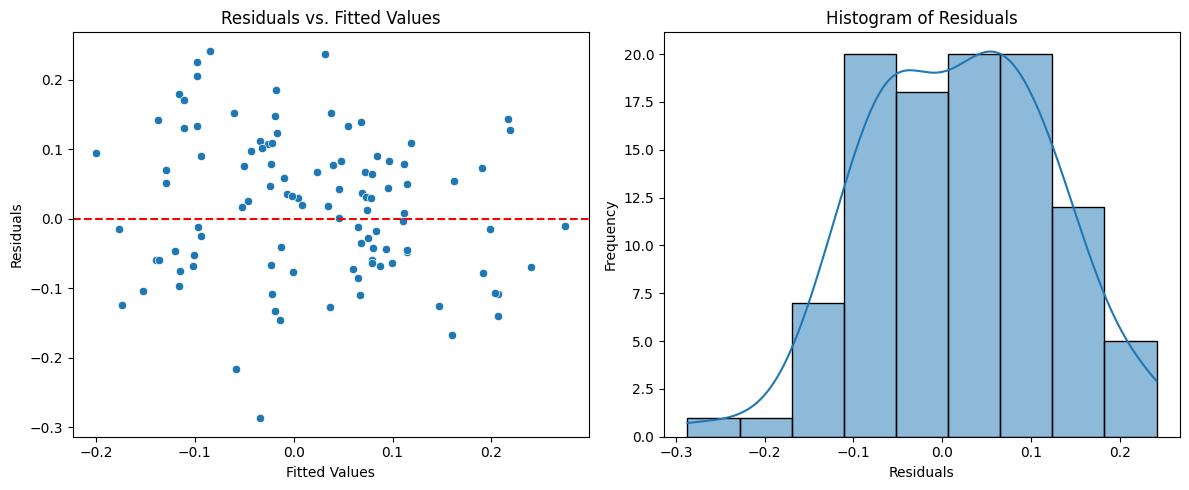

In [ ]:
residuals = y_test - y_hat_test

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_hat_test, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')

plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Multiple Linear Regression Model with Interaction Terms

Given the R^2 values for both training and testing datasets are relatively close, it suggests that the model generalizes well to unseen data without significant overfitting. However, a R^2 test of .409 suggests that this model currently explains only 40% of the variance in our response variable.

To improve this model, we can first try to incorporate interaction terms to account for the correlation between necm_fundinggap_state and avg_tchsalary along with the varying relationships between necm_fundinggap_state and regions as necm_fundinggap_state possesses a stronger correlation with our response variable.

In [ ]:
primary_var = "necm_fundinggap_state"
other_vars = ["avg_tchsalary","east_north_central", "east_south_central", "mid_atlantic", "mountain",
                "new_england","pacific", "south_atlantic", "west_north_central", "west_south_central"]
int_columns = []

# Creation of interaction terms

for var in other_vars:
    term_name = f"{primary_var}_{var}"
    X_train[term_name] = X_train[primary_var] * X_train[var]
    X_test[term_name] = X_test[primary_var] * X_test[var]
    int_columns.append(term_name)

scaler_interaction = StandardScaler()
X_train[int_columns] = scaler_interaction.fit_transform(X_train[int_columns])
X_test[int_columns] = scaler_interaction.transform(X_test[int_columns])

mlr_int_model = LinearRegression()
mlr_int_model.fit(X_train, y_train)

y_hat_train_int = mlr_int_model.predict(X_train)
mse_train_int = mean_squared_error(y_train, y_hat_train_int)
r2_train_int = r2_score(y_train, y_hat_train_int)
print(f"Training MSE with Interactions: {mse_train_int}")
print(f"Training R^2 with Interactions: {r2_train_int}")


Training MSE with Interactions: 0.008285827543618883
Training R^2 with Interactions: 0.6140489804201082


In [56]:
y_hat_test_int = mlr_int_model.predict(X_test)
mse_test_int = mean_squared_error(y_test, y_hat_test_int)
r2_test_int = r2_score(y_test, y_hat_test_int)
print(f"Testing MSE with Interactions: {mse_test_int}")
print(f"Testing R^2 with Interactions: {r2_test_int}")

Testing MSE with Interactions: 0.008797384455697103
Testing R^2 with Interactions: 0.5136908400180036


In [58]:
print(mlr_int_model.coef_)

[ 0.01040974  0.02848138 -0.0459727  -0.03807655  0.04662017 -0.06542098
  0.15509818 -0.00068574  0.14886744 -0.04212982 -0.04063169  0.04977449
 -0.25149205  0.00290014  0.00903836  0.03651772 -0.01180338  0.03978964
 -0.01280985  0.01612084 -0.00165536  0.00482106 -0.0327038 ]


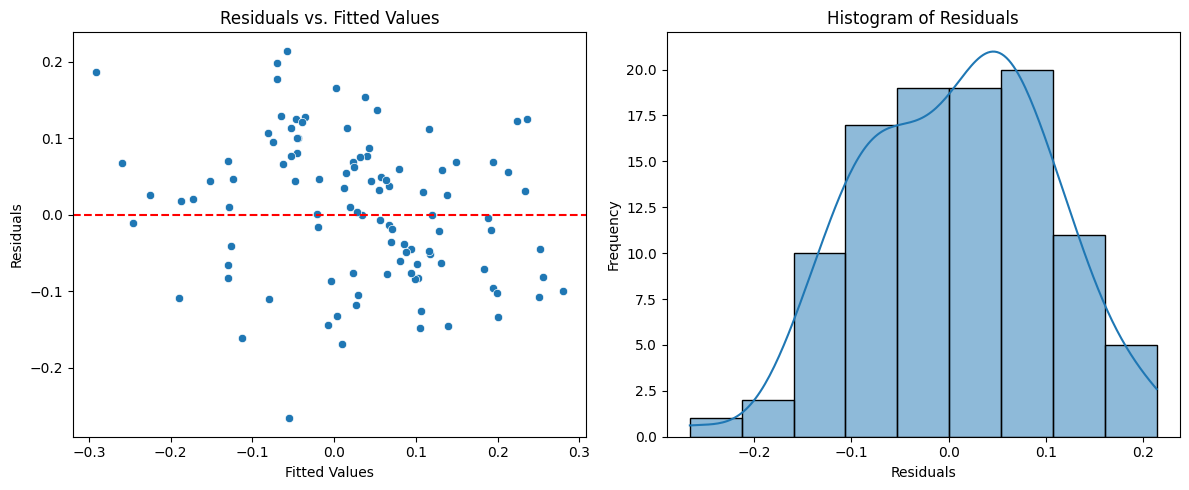

In [57]:
residuals = y_test - y_hat_test_int

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_hat_test_int, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')

plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

With the addition of interaction terms, there's a heightened 

### Polynomial Model with Interaction Terms

In [ ]:
degrees = [2, 3, 4, 5]

mean_cv_scores = []
std_cv_scores = []

for degree in degrees:

    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_train_poly = poly.fit_transform(X_train)
    
    model_poly = LinearRegression()
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = -cross_val_score(model_poly, X_train_poly, y_train, cv=kf, scoring='neg_mean_squared_error')
    
    mean_cv_scores.append(cv_scores.mean())
    std_cv_scores.append(cv_scores.std())

best_degree_cv = degrees[np.argmin(mean_cv_scores)]

print(f"Mean CV MSEs for each degree: {np.round(mean_cv_scores, 2)}")
print(f"Best polynomial degree from CV: {best_degree_cv}")


Mean CV MSEs for each degree: [5.4000000e-01 7.4777900e+03 2.1998765e+05 1.7360806e+05]
Best polynomial degree from CV: 2


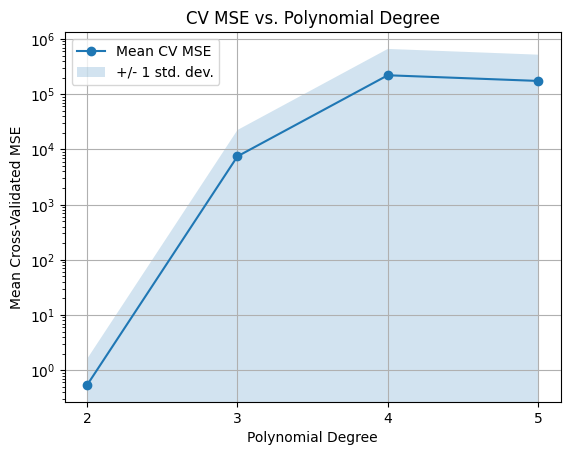

In [60]:
mean_cv_scores = np.array(mean_cv_scores)
std_cv_scores = np.array(std_cv_scores)

plt.plot(degrees, mean_cv_scores, marker='o', label="Mean CV MSE")
plt.fill_between(degrees, np.maximum(0, mean_cv_scores - std_cv_scores), mean_cv_scores + std_cv_scores, alpha=0.2, label="+/- 1 std. dev.")
plt.xlabel("Polynomial Degree")
plt.ylabel("Mean Cross-Validated MSE")
plt.title("CV MSE vs. Polynomial Degree")
plt.yscale('log')
plt.xticks(degrees)
plt.grid(True)
plt.legend()
plt.show()

In [61]:
poly = PolynomialFeatures(degree=best_degree_cv, include_bias=False)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

model_poly = LinearRegression()
model_poly.fit(X_train_poly, y_train)
y_hat_train_poly = model_poly.predict(X_train_poly)
mse_train_poly = mean_squared_error(y_train, y_hat_train_poly)
r2_train_poly = r2_score(y_train, y_hat_train_poly)
print(f"Training MSE with Polynomial Degree {best_degree_cv}: {mse_train_poly}")
print(f"Training R^2 with Polynomial Degree {best_degree_cv}: {r2_train_poly}")

Training MSE with Polynomial Degree 2: 0.0031490209066537536
Training R^2 with Polynomial Degree 2: 0.853319680719472


In [62]:
y_hat_test_poly = model_poly.predict(X_test_poly)
mse_test_poly = mean_squared_error(y_test, y_hat_test_poly)
r2_test_poly = r2_score(y_test, y_hat_test_poly)
print(f"Testing MSE with Polynomial Degree {best_degree_cv}: {mse_test_poly}")
print(f"Testing R^2 with Polynomial Degree {best_degree_cv}: {r2_test_poly}")

Testing MSE with Polynomial Degree 2: 0.004959228424672859
Testing R^2 with Polynomial Degree 2: 0.725859632313819


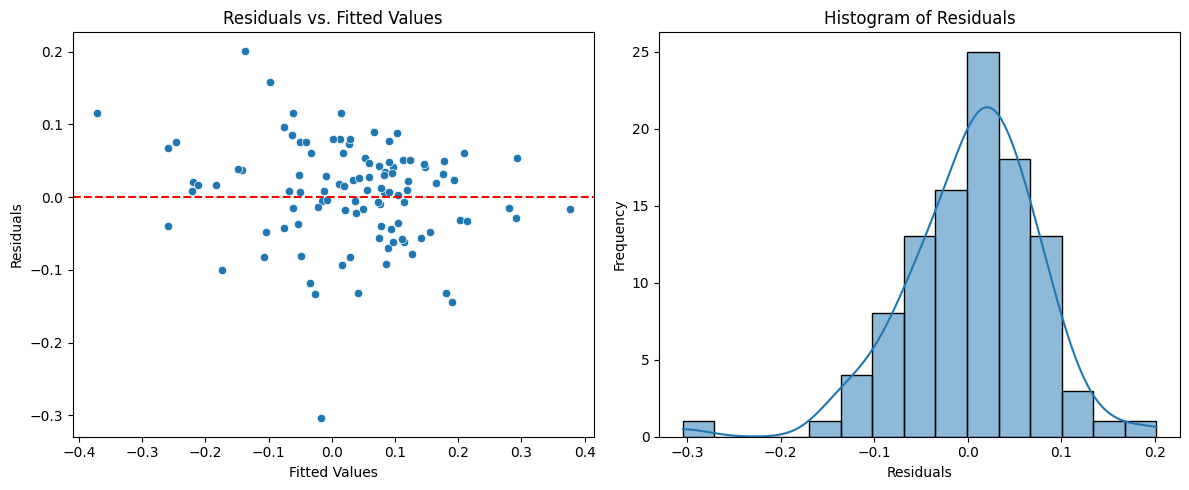

In [63]:
residuals = y_test - y_hat_test_poly

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(x=y_hat_test_poly, y=residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Residuals vs. Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')

plt.subplot(1, 2, 2)
sns.histplot(residuals, kde=True)
plt.title('Histogram of Residuals')
plt.xlabel('Residuals')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()